#Support vector machine
Support vector machine (SVM) is a `supervised machine learning` algorithm that can be used for classification and regression tasks. It works by finding the hyperplane that best separates the data points of different classes in a high-dimensional space. The hyperplane is chosen to maximize the margin between the classes, which helps to improve the generalization of the model.SVM can be used for both linear and non-linear classification. For linear classification, SVM finds the optimal hyperplane that separates the classes. For non-linear classification, SVM uses kernel functions to transform the data into a higher-dimensional space where it can find a linear hyperplane to separate the classes

There are several types of Support Vector Machines (SVM) based on the kernel functions used and the type of problem being solved. Here are some common types of SVM:
1. **Linear SVM**: This type of SVM is used for linearly separable data. It finds a hyperplane that best separates the classes in the feature space.
2. **Non-linear SVM**: This type of SVM is used for non-linearly separable data. It uses kernel functions to transform the data into a higher-dimensional space where a linear hyperplane can be used to separate the classes. Common kernel functions include:
   - **Polynomial Kernel**: Transforms the data into a higher-dimensional space using polynomial functions.
   - **Radial Basis Function (RBF) Kernel**: Also known as the Gaussian kernel, it maps the data into an infinite-dimensional space, allowing for complex decision boundaries.
   - **Sigmoid Kernel**: Uses the sigmoid function to map the data into a higher-dimensional space.

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC,SVR
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score,mean_squared_error,r2_score,mean_absolute_error
from sklearn.preprocessing import LabelEncoder,StandardScaler


In [ ]:
# load dataset 
data = sns.load_dataset('iris')
data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [6]:
# split the X and Y data
x = data.drop('species',axis=1)
y = data['species']

In [7]:
# train test split 
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [9]:
# call the model 
model = SVC()
model.fit(x_train,y_train)

# prediction
y_pred = model.predict(x_test)

In [10]:
# evalute the model 
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


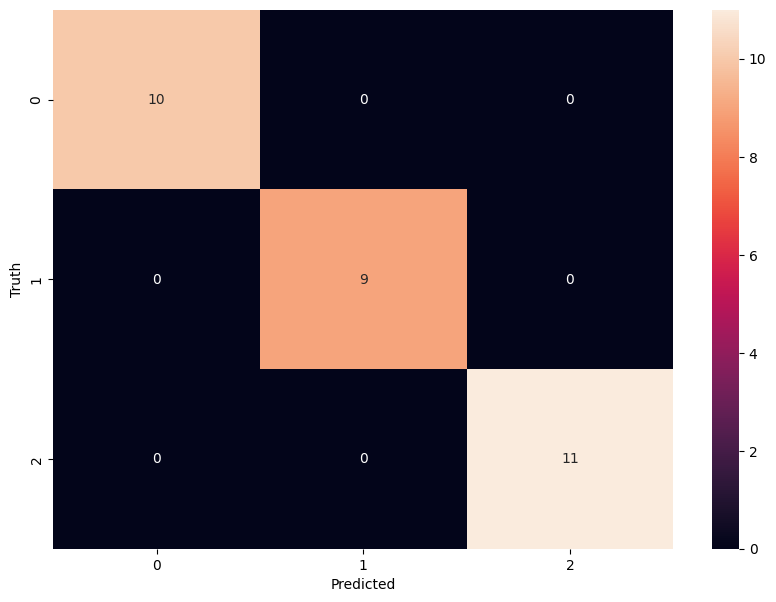

In [12]:
# draw the consfusion matrix
plt.figure(figsize=(10,7))
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.show()

In [13]:
# SVR Example 
X = np.array([[1],
              [2],
              [3],
              [4],
              [5],
              [6],
              [7],
              [8],
              [9],
              [10]])
y = np.array([5, 7, 9, 10, 12, 15, 18, 19, 21, 24])


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [17]:
sc_X = StandardScaler()
sc_y = StandardScaler()

X_train = sc_X.fit_transform(X_train)
X_test = sc_X.transform(X_test)

# reshape y for scaling
y_train = y_train.reshape(-1, 1)

y_train = sc_y.fit_transform(y_train)

In [18]:
model = SVR(kernel='rbf')

model.fit(X_train, y_train.ravel())


,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [19]:
y_pred_scaled = model.predict(X_test)

# Convert predictions back to original scale
y_pred = sc_y.inverse_transform(y_pred_scaled.reshape(-1, 1))


In [22]:
print("Predictions:")
print(y_pred)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nMAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

Predictions:
[[20.67134813]
 [ 7.93145266]]

MAE: 0.6300522678729288
MSE: 0.48780805780286707
R2 Score: 0.9900447335142272


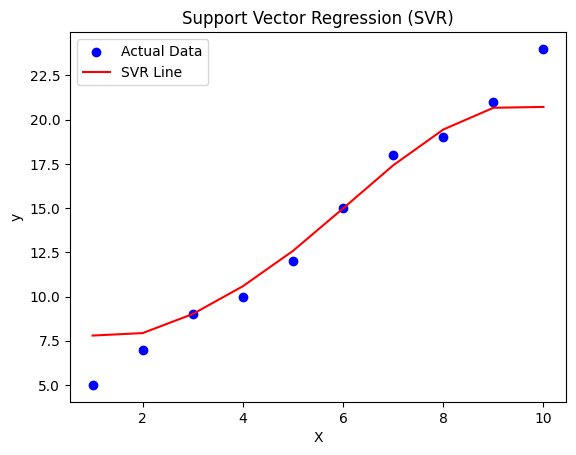

In [23]:
plt.scatter(X, y, color='blue', label='Actual Data')

# Predict for all X values
X_scaled = sc_X.transform(X)
all_predictions_scaled = model.predict(X_scaled)

all_predictions = sc_y.inverse_transform(
    all_predictions_scaled.reshape(-1, 1)
)

plt.plot(X, all_predictions, color='red', label='SVR Line')

plt.xlabel("X")
plt.ylabel("y")
plt.title("Support Vector Regression (SVR)")
plt.legend()

plt.show()